In [ ]:
import numpy as np
import gym
from gym import spaces
from fmi_mlc import fmi_gym
from conversion_bundle.parameters import parameter as PARAMS
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'stable_baselines3'

In [4]:
import warnings
warnings.filterwarnings("ignore")           # elimina tutti i warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
PARAMS

NameError: name 'PARAMS' is not defined

In [29]:
PARAMS['hidden_observation_names']=['DistrictHeating','DistrictCooling','Electricity']
#PARAMS['observation_names'].remove('DistrictHeating')
#PARAMS['observation_names'].remove('DistrictCooling')
#PARAMS['observation_names'].remove('Electricity')

In [30]:
class ComfortEnergyPostProcessor:
    def __init__(self, p):
        self.p = p

        # Comfort band limits (°C)
        self.Th = 20.0
        self.Tc = 26.0

        self.dT_tol = 1.0
        self.lambda_energy = 1e-6

        # Gating comfort on DNI (as in your spec)
        self.dni_gate = 1.0

    def do_calc(self, data, init):
        # data is typically a single-row DataFrame

        # ---- 1) Read DNI safely (must exist) ----
        if "DNI" not in data.columns:
            raise RuntimeError("DNI was not exported from the FMU (From:Variable).")
        dni_val = float(data["DNI"].iloc[0])

        # ---- 2) Energy penalty (always) ----
        # If missing, better to fail loudly (your choice). Here: fail loudly.
        for k in ("DistrictHeating", "DistrictCooling", "Electricity"):
            if k not in data.columns:
                raise RuntimeError(f"Energy variable missing in the FMU: {k}")

        Eh = float(data["DistrictHeating"].iloc[0])
        Ec = float(data["DistrictCooling"].iloc[0])
        Ee = float(data["Electricity"].iloc[0])
        energy_pen = self.lambda_energy * (Eh + Ec + Ee)

        # ---- 3) Comfort penalty (optional: only when DNI is present) ----
        comfort_pen = 0.0

        if dni_val >= self.dni_gate:
            tin_cols = [c for c in data.columns if c.startswith("Tin_")]
            if len(tin_cols) == 0:
                raise RuntimeError("No Tin_* variables found in data. Check observation_names / FMU exports.")

            # Vector of Tin values (shape: [n_zones])
            Tin = data[tin_cols].iloc[0].astype(float).values

            # distance from band
            d = np.where(Tin < self.Th, self.Th - Tin,
                         np.where(Tin > self.Tc, Tin - self.Tc, 0.0))

            comfort_pen = float(np.sum((d / self.dT_tol) ** 2))

        # ---- 4) Final reward (scalar float) ----
        reward = -float(comfort_pen + energy_pen)
        data["reward"] = reward

        return data


In [31]:
PARAMS['postprocessor']=ComfortEnergyPostProcessor
#PARAMS['postprocessor']=ComfortEnergyPostProcessor(PARAMS)

In [ ]:
class SB3Wrapper(gym.Wrapper):
    """
    SB3Wrapper around an existing fmi_gym environment.

    Semantics:

    - RL episode: fixed duration in hours (episode_hours, e.g. 48h).
    - Physical FMI episode: runs from the initial time up to fmu_final_time.
    - reset of fmi_mlc (env.reset()) is called ONLY when
      the physical simulation has finished (done_env == True).

    - If ONLY the RL episode ends (e.g. 2 days) but the physical simulation continues:
        * we return done=True to the agent (end of RL episode)
        * we DO NOT call env.reset()
        * the FMU continues from its current physical state
        * the next RL episode starts from the same observation (last_obs)
          and continues the same physical trajectory.

    - Action space:
        * SB3 sees MultiDiscrete([2] * N_shades)
        * 0 -> 0.0, 1 -> 7.0
        * N_shades = len(env.parameter["action_names"])
          (one discrete action per shading device)

    - Observation space: identical to that of the wrapped fmi_gym environment.
    """

    def __init__(self, env: fmi_gym, episode_hours: float = 48.0):
        # env is already a configured fmi_gym environment
        super().__init__(env)

        # Keep a direct alias for clarity
        self.base_env = env

        # ----- Action space: MultiDiscrete [0, 1] for each FMI action -----
        # We read the list of action names from the fmi_gym parameters
        self.action_names = self.base_env.parameter["action_names"]
        self.n_actions = len(self.action_names)

        # Each action can be 0 to 7; SB3 sees this as a MultiDiscrete space
        self.action_space = spaces.MultiDiscrete([8] * self.n_actions)

        # ----- Observation space: identical to FMI-MLC / fmi_gym -----
        self.observation_space = self.base_env.observation_space

        # ----- RL episodes: duration expressed in number of steps -----
        self.episode_hours = episode_hours
        self.dt = self.base_env.parameter["fmu_step_size"]  # [s] FMU time step

        # Compute maximum number of RL steps per episode:
        # episode_hours [h] → seconds, then divide by FMU step size dt [s].
        self.max_steps_per_episode = int(
            (self.episode_hours * 3600.0) / self.dt
        )

        # Internal wrapper state
        self.rl_steps = 0          # number of RL steps in the current episode
        self.env_done = False      # True if fmi_gym reported end of physical simulation
        self.last_obs = None       # last observation returned to the agent

    # ------------------------------------------------------------------
    # RESET
    # ------------------------------------------------------------------
    def reset(self, **kwargs):
        """
        Reset from the agent's point of view (RL episode reset).

        Behavior:

        - If the physical simulation is NOT finished (env_done == False):
             -> DO NOT call env.reset()
             -> DO NOT touch the FMU state
             -> only reset the RL step counter and
                return the last observation (last_obs).
                This starts a new RL episode over the same physical trajectory.

        - If the physical simulation IS finished (env_done == True):
             -> call env.reset() ONCE (true FMU reset)
             -> reset env_done and rl_steps
             -> return the new initial observation from the environment.

        Notes:
        - On the VERY first call, last_obs is None, so we must reset the base
          environment to obtain the initial observation.
        """

        # Case 1: very first reset call, no previous observation exists yet
        if self.last_obs is None:
            obs = self.base_env.reset()
            self.rl_steps = 0
            self.env_done = False
            self.last_obs = obs
            return obs

        # Case 2: physical simulation NOT finished -> logical RL reset only
        if not self.env_done:
            # Do not touch the FMU: the new RL episode starts from the last
            # physical state and observation already computed.
            self.rl_steps = 0
            return self.last_obs

        # Case 3: physical simulation FINISHED -> true FMI-MLC reset
        obs = self.base_env.reset()
        self.rl_steps = 0
        self.env_done = False
        self.last_obs = obs
        return obs

    # ------------------------------------------------------------------
    # STEP
    # ------------------------------------------------------------------
    def step(self, action):
        """
        RL step wrapper.

        - action: MultiDiscrete[0..1]^N_shades as seen by SB3.

        - Mapping from SB3 discrete action to FMU continuous action:
              0 -> 0.0
              1 -> 7.0
          applied element-wise to each shading device/action.

        - The mapped action is passed to fmi_gym.step().

        - Internal counters:
            * rl_steps is incremented every time step() is called.
            * env_done stores whether the underlying physical simulation has ended.

        - done_rl (the 'done' returned to SB3) is True if:
            * we reached the RL episode duration in steps
              (rl_steps >= max_steps_per_episode), OR
            * the physical simulation (fmi_gym) signaled done_env == True.

          In the first case only (RL episode ends but env_done == False),
          the FMU continues from its current state and the next reset()
          will just restart the RL episode logically from last_obs.
        """

        # Map discrete {0..7} actions to continuous {0.0..7.0} values for the FMU
        fmi_action = action.astype(float)
        # Delegate the step to the underlying fmi_gym environment
        obs, reward, done_env, info = self.base_env.step(fmi_action)

        # Update internal state with the latest observation and physical done flag
        self.last_obs = obs
        self.env_done = bool(done_env)

        # Increase RL step counter for the current RL episode
        self.rl_steps += 1

        # RL episode termination:
        # - either we reached the maximum number of steps for this episode
        # - or the underlying physical simulation has ended
        done_rl = (self.rl_steps >= self.max_steps_per_episode) or self.env_done

        # Return the observation, reward, RL done flag, and info dict
        return obs, reward, done_rl, info



In [33]:
from stable_baselines3.common.callbacks import BaseCallback
import numpy as np

class EpisodeStatsCallback(BaseCallback):
    """
    Custom callback to collect per-episode statistics during training with Stable-Baselines3.

    What it stores:
    - episode_returns : list of total rewards per episode (sum of step rewards)
    - episode_lengths : list of episode lengths in number of environment steps
    - episode_metrics : list of dicts, each containing ALL logged train/* metrics
                        at the end of each episode (e.g., losses, entropy, etc.)

    Notes:
    - Works with both single and vectorized environments (n_envs >= 1).
    - For vectorized envs, it tracks cumulative returns and lengths separately
      for each environment index.
    """

    def __init__(self, verbose=0):
        """
        Constructor.

        :param verbose: verbosity level (0 = silent, >0 prints episode summaries).
        """
        super().__init__(verbose)

        # Total return (sum of rewards) per completed episode
        self.episode_returns = []

        # Length in steps per completed episode
        self.episode_lengths = []

        # Here we store ALL metrics logged by the SB3 logger (only train/*),
        # one dict per completed episode.
        self.episode_metrics = []  # <--- here we store ALL metrics

    def _on_training_start(self):
        """
        Called once at the beginning of training.

        Initializes per-environment accumulators:
        - _ep_ret: cumulative reward for the current ongoing episode in each env
        - _ep_len: number of steps taken in the current ongoing episode in each env
        """
        # Number of parallel environments (1 for non-vectorized envs)
        n_envs = getattr(self.training_env, "num_envs", 1)

        # Cumulative reward per environment (current episode)
        self._ep_ret = np.zeros(n_envs)

        # Number of steps per environment (current episode)
        self._ep_len = np.zeros(n_envs, dtype=int)

    def _on_step(self):
        """
        Called at every environment step.

        Responsibilities:
        - Read rewards and done flags for each environment.
        - Accumulate episode return and length for each env index.
        - When an episode ends (done=True for that env):
            * store total return and length in the public lists
            * extract ALL train/* metrics from the SB3 logger
              and store them in episode_metrics
            * optionally print a summary if verbose > 0
            * reset per-episode accumulators for that env index
        """

        # Get rewards and done flags from the locals dict.
        # SB3 can use either "rewards"/"dones" or "reward"/"done"
        rewards = np.atleast_1d(self.locals.get("rewards", self.locals.get("reward")))
        dones   = np.atleast_1d(self.locals.get("dones",   self.locals.get("done")))

        # Iterate over each environment in the vectorized setup
        for i, (r, d) in enumerate(zip(rewards, dones)):
            # Accumulate reward and step count for the current episode of env i
            self._ep_ret[i] += float(r)
            self._ep_len[i] += 1

            # If the environment signals the end of an episode
            if d:
                # Final return and length for the completed episode in env i
                R = float(self._ep_ret[i])
                L = int(self._ep_len[i])

                # Store episode-level stats
                self.episode_returns.append(R)
                self.episode_lengths.append(L)

                # Access all logged metrics from the SB3 logger
                metrics = self.model.logger.name_to_value

                # Extract ALL metrics whose key starts with "train/"
                # and strip the "train/" prefix from the keys.
                ep_m = {
                    k.replace("train/", ""): v
                    for k, v in metrics.items()
                    if k.startswith("train/")
                }
                self.episode_metrics.append(ep_m)

                # Optional console output
                if self.verbose:
                    print(
                        f"[Episode {len(self.episode_returns)}] "
                        f"R={R:.2f}, len={L}, metrics={ep_m}"
                    )

                # Reset accumulators for this environment index
                self._ep_ret[i] = 0.0
                self._ep_len[i] = 0

        # Returning True tells SB3 to continue training
        return True




In [34]:
from stable_baselines3.common.callbacks import BaseCallback
from tqdm.auto import tqdm  # make sure `tqdm` is installed
import sys

class TqdmProgressCallback(BaseCallback):
    """
    Callback that displays a live tqdm progress bar during SB3 training.

    Purpose:
    --------
    Stable-Baselines3 normally prints periodic logs, but does not provide
    a continuous progress bar. This callback fills that gap by showing a
    clean tqdm progress bar that updates in-place without producing new lines.

    How it works:
    -------------
    - At the beginning of training, a tqdm bar is created with `total_timesteps`.
    - At every call to `_on_step()`, we compute how many timesteps have passed
      since the last update and increment the bar by that delta.
      (This avoids unnecessary redraws and prevents line flooding.)
    - At the end of training, the bar is forced to completion and closed.

    Notes:
    ------
    - Uses `sys.stdout` to ensure correct behavior inside Jupyter notebooks
      and terminal environments.
    - `leave=False` ensures the bar disappears after completion rather than
      leaving a residual printed line.
    """

    def __init__(self, total_timesteps):
        """
        :param total_timesteps: the total number of agent training timesteps,
                                typically the same value passed to model.learn().
        """
        super().__init__()
        self.total_timesteps = total_timesteps
        self.pbar = None       # tqdm progress bar object
        self._last = 0         # last timestep count used to compute incremental updates

    def _on_training_start(self):
        """
        Called once at the beginning of training.

        Initializes the tqdm progress bar. The bar dynamically adapts its width
        to the terminal/notebook and updates smoothly without extra lines.
        """
        self.pbar = tqdm(
            total=self.total_timesteps,
            desc="Training",
            leave=False,          # do not leave a new line after completion
            file=sys.stdout,      # ensures proper display in notebook and terminal
            mininterval=0.1,      # minimum time between updates
            dynamic_ncols=True,   # adjust to terminal width
        )

    def _on_step(self):
        """
        Called at every environment step.

        We update the progress bar ONLY by the number of newly completed
        timesteps, to avoid unnecessary redraws.

        SB3 provides `self.num_timesteps`, which is the global count of steps
        since training started. We store the previous value in `self._last` to
        compute the delta.
        """
        delta = self.num_timesteps - self._last

        if delta > 0:
            self.pbar.update(delta)
            self._last = self.num_timesteps

        return True  # continue training

    def _on_training_end(self):
        """
        Called once at the end of training.

        Ensures the progress bar reaches 100% and then closes it cleanly.
        """
        # Force completion if not already full
        self.pbar.update(self.total_timesteps - self._last)
        self.pbar.close()


In [35]:
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import CallbackList, ProgressBarCallback

# 1) FMI-MLC parameters
#    Here we configure the FMU simulation time window and behavior.

# Example:
PARAMS["fmu_start_time"] = 185 * 24 * 3600   # start day of year (in seconds) → day 185
PARAMS["fmu_final_time"] = 220 * 24 * 3600   # end day of year (in seconds) → day 220

# If False: the physical simulation is allowed to reset between episodes
# (this can interact with ignore_reset logic inside your fmi_gym / FMU wrapper).
PARAMS["ignore_reset"] = False               # physical simulation does NOT continue between episodes unconditionally

# FMU log level (0 = silent / minimal logging, higher = more verbose)
# PARAMS["fmu_loglevel"] = 0 uncomment if line below doesn't work
PARAMS["fmu-loglevel"] = 0

# 2) Create base FMI-MLC environment
#    fmi_gym is assumed to be a custom gym.Env that wraps the FMU.
base_env = fmi_gym(parameter=PARAMS)

# 3) Wrap with SB3Wrapper to:
#    - expose a MultiDiscrete action space for the blinds/shades
#    - handle RL episode length vs physical simulation length
env = SB3Wrapper(base_env)


In [36]:
model = A2C(
    "MlpPolicy",
    env,
    gamma=0.997

)
total_timesteps = 500_000



In [37]:

metrics_cb = EpisodeStatsCallback(verbose=0)
progress_cb = TqdmProgressCallback(total_timesteps=total_timesteps)
callback = CallbackList([progress_cb, metrics_cb])



model.learn(
    total_timesteps=total_timesteps,
    callback=callback,
    progress_bar=False,  # DISATTIVA la barra interna SB3
)

Reading input and weather file for preprocessor program.
The IDF version of the input file ///tmp/JModelica.org/jm_tmpccdexqvp//resources//shading_edited_Res_Flat2_IDF_optimized_final.idf starts with 9
Successfully finish reading weather file.
This is the Begin Month: 7
This is the Day of the Begin Month: 5
This is the End Month: 8
This is the Day of the End Month: 8
Day of week was left blank in input file.
This is the New Day of Week:  
Running EPMacro...
ExpandObjects Started.
No expanded file generated.
ExpandObjects Finished. Time:     0.023
EnergyPlus Starting
EnergyPlus, Version 9.6.0-4b123cf80f, YMD=2026.01.29 15:24
Initializing Response Factors
Calculating CTFs for "PAVIMENTO INTERNO DI PROGETTO"
Calculating CTFs for "_FLATROOF_MOD"
Calculating CTFs for "_FLATROOF_MOD"
Calculating CTFs for "_WALL_MOD"
Calculating CTFs for "PARETE SEMI-ESPOSTA DI PROGETTO"
Calculating CTFs for "115MM SINGLE LEAF BRICK (PLASTERED BOTH SIDES)"
Calculating CTFs for "PAVIMENTO CONTROTERRA DI PROGET

[WARNING][Slave] [warning][FMU status:Warning] fmiInitializeSlave: The StopTimeDefined parameter is set to 0. This is not valid. EnergyPlus FMU requires a stop time and will use the stop time 19008000.000000 which is provided.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The sockfd is 60.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The port number is 50593.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: This hostname is 75e5af02e477.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: TCPServer Server waiting for clients on port: 50593.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The number of input variables is 9.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The number of output variables is 9.

[INFO][Slave] [ok][FMU status:OK] Get input file from resource folder ///tmp/JModelica.org/jm_tmpccdexqvp//resources//.

[INFO][Slave] [ok][FMU status:OK] Searching for following pattern .idf

[INFO][Slave] [ok][FMU status:OK] Read directory

Number of outputs in ExternalInterface = 9
Number of inputs  in ExternalInterface = 9
Calculating Detailed Daylighting Factors, Start Date=07/05
Warming up {2}
Warming up {3}
Warming up {4}
Warming up {5}
Warming up {6}
Warming up {7}
Warming up {8}
Warming up {9}
Warming up {10}
Starting Simulation at 07/05/2002 for SENZA TITOLO (01-01:31-12)
ExternalInterface starts first data exchange.
Training:   1%|          | 2876/500000 [00:53<5:05:36, 27.11it/s]Updating Shadowing Calculations, Start Date=07/25/2002
Updating Detailed Daylighting Factors, Start Date=07/25
Training:   1%|          | 5037/500000 [01:38<2:28:28, 55.56it/s]Writing tabular output file results using tab format.
Writing tabular output file results using HTML format.
 ReadVarsESO program starting.
 ReadVars Run Time=00hr 00min  0.21sec
 ReadVarsESO program completed successfully.
 ReadVarsESO program starting.
 ReadVars Run Time=00hr 00min  0.13sec
 ReadVarsESO program completed successfully.
EnergyPlus Run Time=00hr 01m

[INFO][Slave] [ok][FMU status:OK] fmiTerminateSlave: fmiFreeInstanceSlave must be called to free the FMU instance.

[INFO][Slave] [ok][FMU status:OK] fmiFreeSlaveInstance: The function fmiFreeSlaveInstance of instance Slave is executed.

EnergyPlus Completed Successfully.
[INFO][Slave] [ok][FMU status:OK] freeInstanceResources: Slave will be freed.



Reading input and weather file for preprocessor program.
Training:   1%|          | 5039/500000 [01:49<2:28:28, 55.56it/s]The IDF version of the input file ///tmp/JModelica.org/jm_tmpupiokld9//resources//shading_edited_Res_Flat2_IDF_optimized_final.idf starts with 9
Successfully finish reading weather file.
This is the Begin Month: 7
This is the Day of the Begin Month: 5
This is the End Month: 8
This is the Day of the End Month: 8
Day of week was left blank in input file.
This is the New Day of Week:  
Running EPMacro...
ExpandObjects Started.
No expanded file generated.
ExpandObjects Finished. Time:     0.026
EnergyPlus Starting
EnergyPlus, Version 9.6.0-4b123cf80f, YMD=2026.01.29 15:26
Initializing Response Factors
Calculating CTFs for "PAVIMENTO INTERNO DI PROGETTO"
Calculating CTFs for "_FLATROOF_MOD"
Calculating CTFs for "_FLATROOF_MOD"
Calculating CTFs for "_WALL_MOD"
Calculating CTFs for "PARETE SEMI-ESPOSTA DI PROGETTO"
Calculating CTFs for "115MM SINGLE LEAF BRICK (PLASTERED B

...

olar Calculations
Allocate Solar Module Arrays
Initializing Zone and Enclosure Report Variables
Initializing Surface (Shading) Report Variables
Computing Interior Solar Absorption Factors
Determining Shadowing Combinations
Computing Window Shade Absorption Factors
Proceeding with Initializing Solar Calculations
Initializing Surfaces
Initializing Outdoor environment for Surfaces
Setting up Surface Reporting Variables
Initializing Temperature and Flux Histories
Initializing Window Shading
Computing Interior Absorption Factors
Computing Interior Diffuse Solar Absorption Factors
Initializing Solar Heat Gains
Initializing Internal Heat Gains
Initializing Interior Solar Distribution
Initializing Interior Convection Coefficients
Gathering Information for Predefined Reporting
Completed Initializing Surface Heat Balance
Calculate Outside Surface Heat Balance
Calculate Inside Surface Heat Balance
Calculate Air Heat Balance
Initializing HVAC
Warming up
Calculating Detailed Daylighting Factors, St

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The sockfd is 60.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The port number is 56051.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: This hostname is 75e5af02e477.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: TCPServer Server waiting for clients on port: 56051.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The number of input variables is 9.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The number of output variables is 9.

[INFO][Slave] [ok][FMU status:OK] Get input file from resource folder ///tmp/JModelica.org/jm_tmpwhjv2qr4//resources//.

[INFO][Slave] [ok][FMU status:OK] Searching for following pattern .idf

[INFO][Slave] [ok][FMU status:OK] Read directory and search for *.idf, *.epw, or *.idd file.

[INFO][Slave] [ok][FMU status:OK] Read directory and search for *.idf, *.epw, or *.idd file.

[INFO][Slave] [ok][FMU status:OK] Read directory and search for *.idf, *.epw, or *.idd f

Training:  99%|█████████▉| 496793/500000 [3:05:12<00:38, 83.11it/s]Updating Shadowing Calculations, Start Date=07/25/2002
Updating Detailed Daylighting Factors, Start Date=07/25
Training: 100%|█████████▉| 498957/500000 [3:05:40<00:12, 83.76it/s]Writing tabular output file results using tab format.
Writing tabular output file results using HTML format.
 ReadVarsESO program starting.
 ReadVars Run Time=00hr 00min  0.15sec
 ReadVarsESO program completed successfully.
 ReadVarsESO program starting.
 ReadVars Run Time=00hr 00min  0.08sec
 ReadVarsESO program completed successfully.
EnergyPlus Run Time=00hr 01min  6.09sec
Reading input and weather file for preprocessor program.


[INFO][Slave] [ok][FMU status:OK] fmiTerminateSlave: fmiFreeInstanceSlave must be called to free the FMU instance.

[INFO][Slave] [ok][FMU status:OK] fmiFreeSlaveInstance: The function fmiFreeSlaveInstance of instance Slave is executed.

EnergyPlus Completed Successfully.
[INFO][Slave] [ok][FMU status:OK] freeInstanceResources: Slave will be freed.

[WARNING][Slave] [warning][FMU status:Warning] fmiInitializeSlave: The StopTimeDefined parameter is set to 0. This is not valid. EnergyPlus FMU requires a stop time and will use the stop time 19008000.000000 which is provided.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The sockfd is 60.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The port number is 48525.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: This hostname is 75e5af02e477.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: TCPServer Server waiting for clients on port: 48525.

[INFO][Slave] [ok][FMU status:OK] fmiInitializeSlave: The number of inpu

The IDF version of the input file ///tmp/JModelica.org/jm_tmpvag_hala//resources//shading_edited_Res_Flat2_IDF_optimized_final.idf starts with 9
Successfully finish reading weather file.
This is the Begin Month: 7
This is the Day of the Begin Month: 5
This is the End Month: 8
This is the Day of the End Month: 8
Day of week was left blank in input file.
This is the New Day of Week:  
Running EPMacro...
ExpandObjects Started.
No expanded file generated.
ExpandObjects Finished. Time:     0.022
EnergyPlus Starting
EnergyPlus, Version 9.6.0-4b123cf80f, YMD=2026.01.29 18:30
Initializing Response Factors
Calculating CTFs for "PAVIMENTO INTERNO DI PROGETTO"
Calculating CTFs for "_FLATROOF_MOD"
Calculating CTFs for "_FLATROOF_MOD"
Calculating CTFs for "_WALL_MOD"
Calculating CTFs for "PARETE SEMI-ESPOSTA DI PROGETTO"
Calculating CTFs for "115MM SINGLE LEAF BRICK (PLASTERED BOTH SIDES)"
Calculating CTFs for "PAVIMENTO CONTROTERRA DI PROGETTO"
Initializing Window Optical Properties
Initializing S

In [38]:
import numpy as np
import matplotlib.pyplot as plt

def plot_from_callback(cb: EpisodeStatsCallback, rolling_window: int = 50):
    """
    Plot:
      - episode returns (optionally with a moving average)
      - all train/* metrics stored in cb.episode_metrics

    Works with PPO, DQN, DDPG, TD3, A2C, SAC, etc.

    Parameters
    ----------
    cb : EpisodeStatsCallback
        Callback instance that collected episode statistics during training.
    rolling_window : int, optional
        Window size (in episodes) for the moving average of the return.
        If None, the moving average is not plotted.
    """
    # ---------- 1) Reward per episode ----------
    # Convert list of returns to a NumPy array for easy processing
    R = np.array(cb.episode_returns, dtype=float)

    plt.figure(figsize=(10, 4))
    plt.plot(R, label="Return per episode")

    # Optional moving average smoothing over episodes
    if rolling_window is not None and len(R) >= rolling_window:
        kernel = np.ones(rolling_window) / rolling_window
        R_ma = np.convolve(R, kernel, mode="valid")
        x_ma = np.arange(len(R_ma)) + (rolling_window - 1)
        plt.plot(x_ma, R_ma, label=f"Moving average ({rolling_window} episodes)")

    plt.xlabel("Episode")
    plt.ylabel("Return")
    plt.title("Episode returns")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # If no metrics were stored, there is nothing more to plot
    if not cb.episode_metrics:
        print("No metrics found in episode_metrics.")
        return

    # ---------- 2) Metrics from the logger ----------
    # Collect the union of all metric keys across all episodes
    all_keys = set()
    
    for d in cb.episode_metrics:
        all_keys.update(d.keys())
    all_keys = sorted(all_keys)

    # Build an array for each metric, padding missing values with NaN
    metrics_arr = {}
    for key in all_keys:
        vals = []
        for d in cb.episode_metrics:
            v = d.get(key, np.nan)
            vals.append(np.nan if v is None else v)
        metrics_arr[key] = np.array(vals, dtype=float)

    # Plot all metrics on a single figure (multiple curves)
    
    for key, vals in metrics_arr.items():
        plt.figure(figsize=(12, 6))
        # Skip metrics that were never logged (all NaN)
        if np.all(np.isnan(vals)):
            continue
        plt.plot(vals, label=key)

        plt.xlabel("Episode")
        plt.ylabel("Metric value")
        plt.title("Training metrics (SB3 logger)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


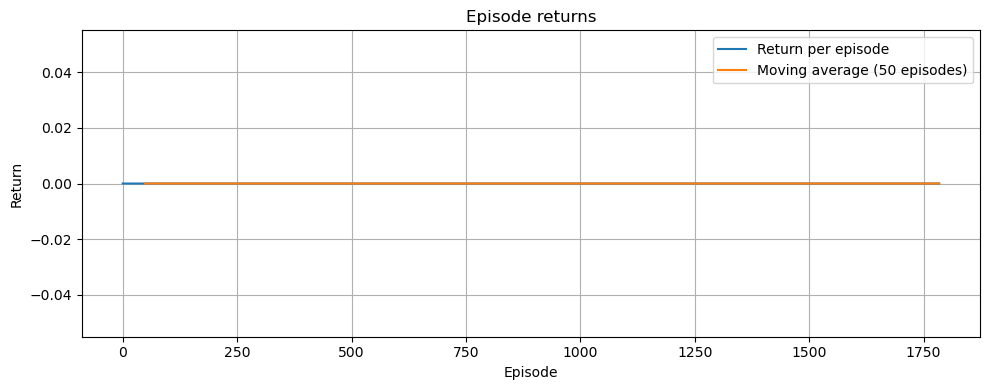

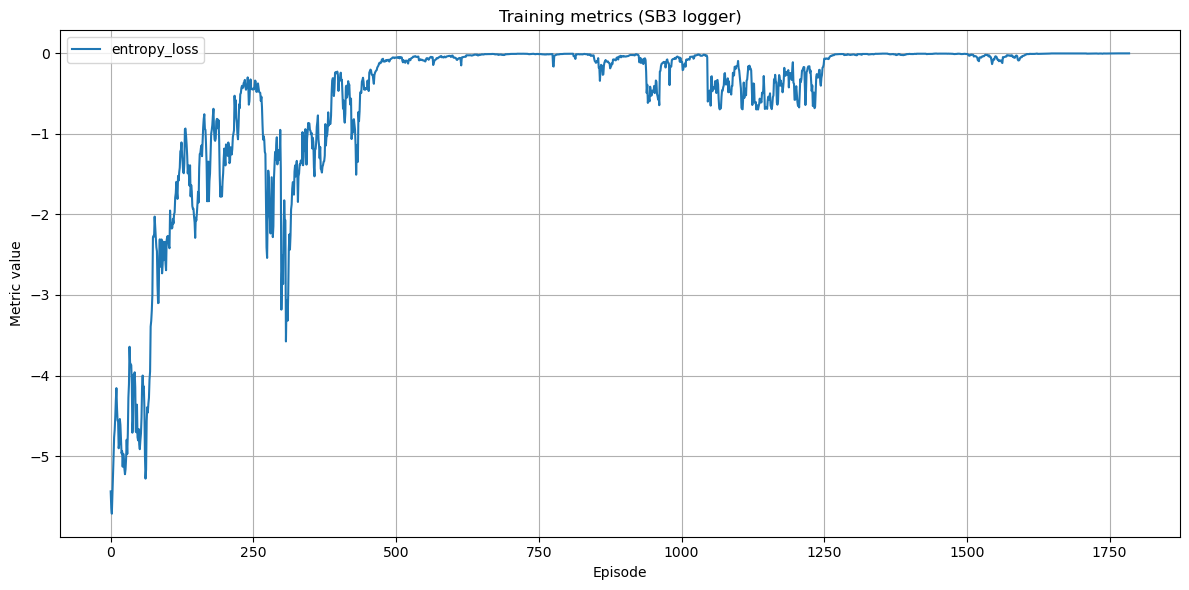

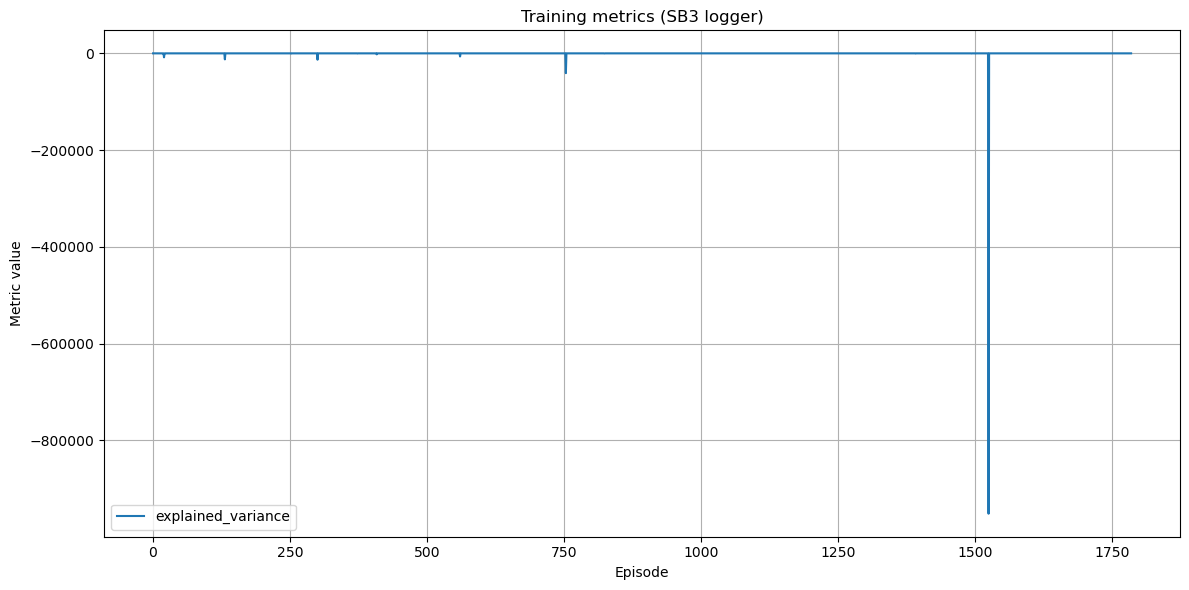

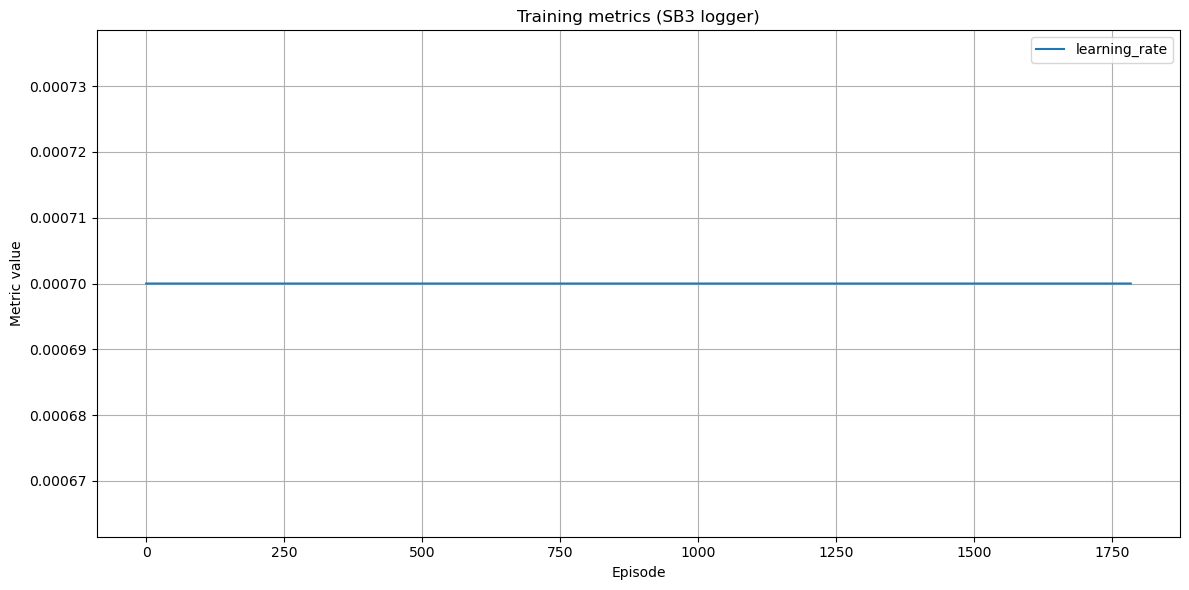

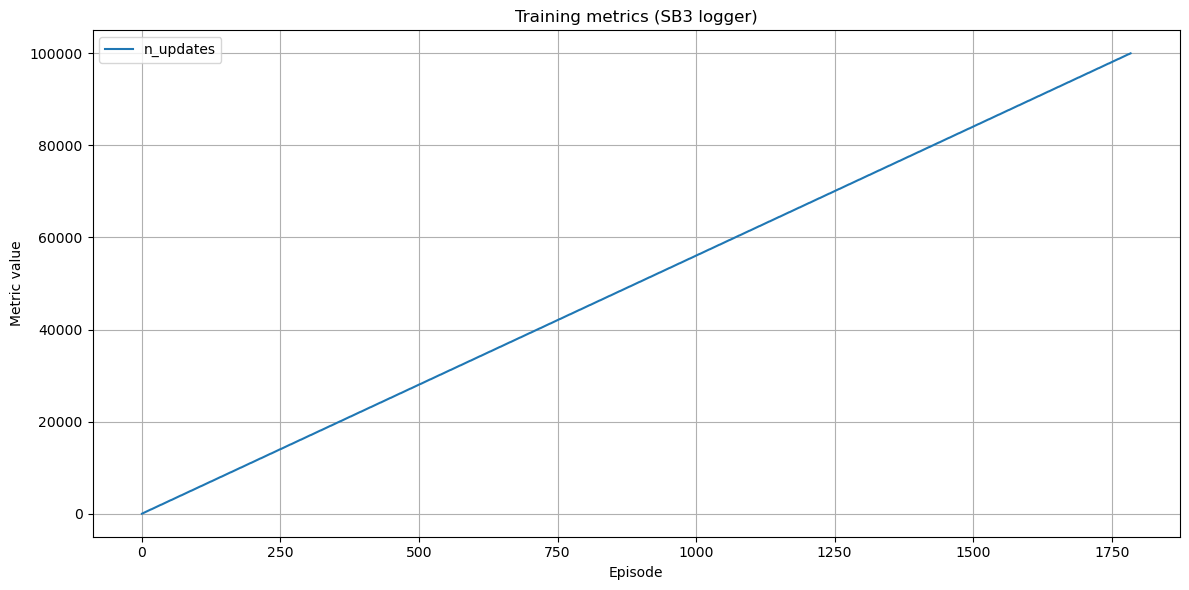

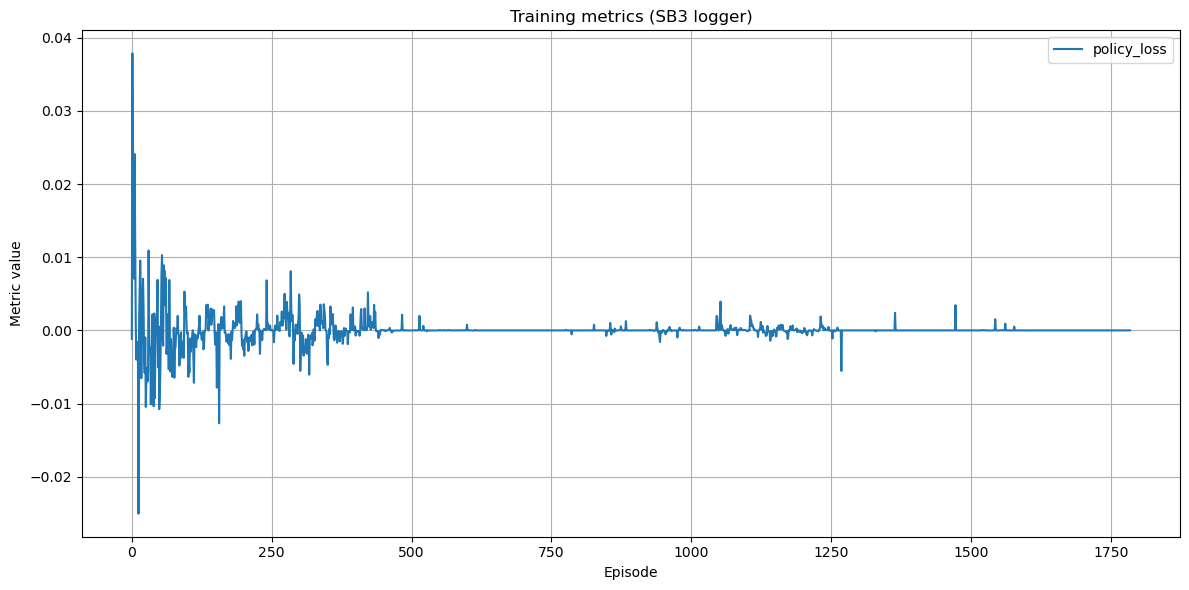

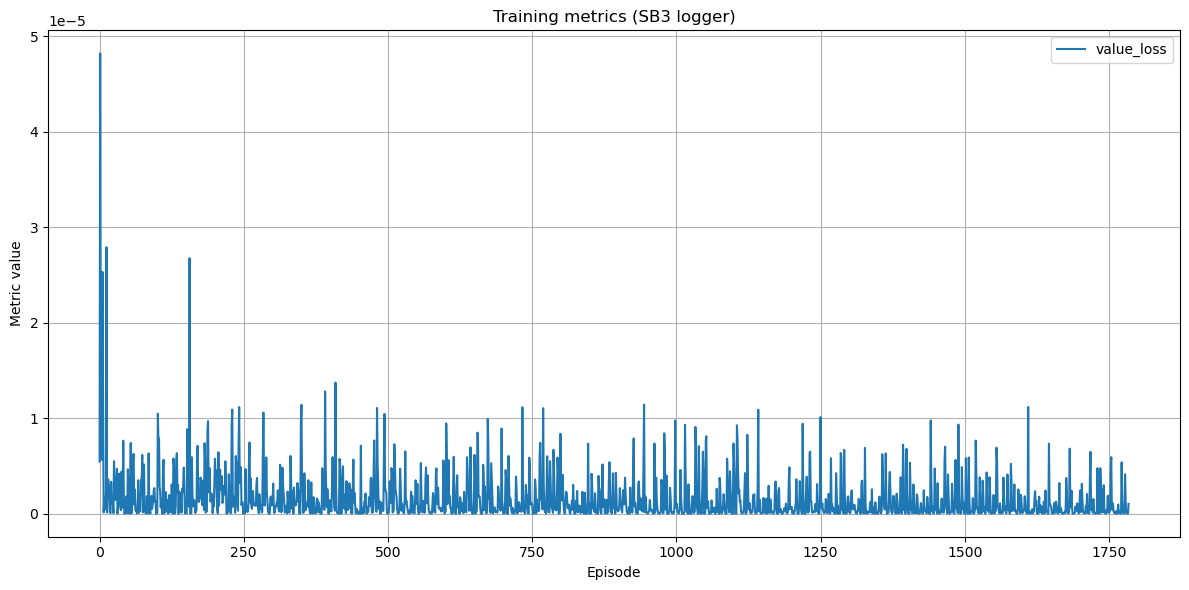

In [40]:
plot_from_callback(metrics_cb, rolling_window=50)


In [41]:
# Save the trained model
model.save("trained_a2c_model")

print("✅ Model saved as 'trained_a2c_model.zip'")

✅ Model saved as 'trained_a2c_model.zip'


In [43]:
# --- CELL 2 ---
# Load the model and run predictions WITHOUT an environment

from stable_baselines3 import A2C
import numpy as np

# Load the saved model
model = A2C.load("trained_a2c_model")
print("✅ Model loaded")

# Example observation: build it from your real observation dictionary
# Assuming you have:
# obs_dict = {"Tin_1": 24.1, "Tin_2": 25.0, ...}
# Dummy observation (example, replace with real values)
obs_dict = {
    "Tin_Flat2_Zona1": 25.0,
    "Tout": 30.0,
    "DNI": 700.0,
    "Tin_Flat2_Zona2": 24.8,
    "Tin_Flat2_Zona3": 24.9,
    "Tin_Flat2_Zona4": 25.1,
}

# Convert obs_dict to a numpy array in the correct order
obs = np.array([obs_dict[n] for n in PARAMS["observation_names"]], dtype=np.float32)

# Predict action
action, _ = model.predict(obs, deterministic=True)
print("Predicted action:", action)


✅ Model loaded
Predicted action: [0 1 0 0 0 1 0 1 1]
